# Connectivity → VMPFC activation prediction

对应论文 Study 3。每个被试用 FC（功能连接）或 SC（结构连接 / DTI）作为输入，预测其 VMPFC 三个子区（affect / valuation / social）的 task fMRI 激活，五折交叉验证后得到真实 vs 预测的相关系数（Prediction Accuracy, Pearson r）。

本 notebook 在 5 个数据集上分别复现条形图：

| 数据集 | 来源 | 说明 |
|---|---|---|
| `inhouse_BNA` | 课题组内部数据，BNA 图谱 ROI | 主结果，含 1000 次置换 |
| `inhouse_HOA` | 课题组内部数据，HOA 图谱 ROI | 图谱稳健性 |
| `HCP3T_BNA` | HCP 3T 数据，BNA 图谱 ROI | 跨数据集复现 |
| `inhouse_predict_HCP_3T_BNA` | 用 inhouse 训练的模型预测 HCP 3T | 跨数据集泛化 |
| `inhouse_predict_HCP_7T_BNA` | 用 inhouse 训练的模型预测 HCP 7T | 跨场强泛化 |

Noise ceiling（test-retest 上限）用虚线绘制，permutation 基线（y=0）用实线绘制。统计学显著性由用户在 PPT 中后续添加。

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'

In [2]:
DATA = Path('../data')
PLOTS = Path('../plots')
PLOTS.mkdir(exist_ok=True)
PLOT_PARAMS = dict(bbox_inches='tight', transparent=True, dpi=600)

# 三个 motif 的展示顺序（与论文 Fig. 配色一致：红 / 黄 / 蓝）
Y_NAMES = ['affect', 'valuation', 'social']
X_NAMES = ['FC', 'SC']

# 每个 (motif, modality) 一种颜色：FC = 浅, SC = 深
PALETTE = {
    'affect_FC':    '#eab5bc', 'affect_SC':    '#d66c7a',  # red pair
    'valuation_FC': '#fae9a4', 'valuation_SC': '#f6d44a',  # yellow pair
    'social_FC':    '#c4d9e9', 'social_SC':    '#8ab3d4',  # blue pair
}

# Noise ceiling（顺序：affect, valuation, social）
# 来源：原 conn_pred_act.ipynb cell 2
CEILING_INHOUSE = [0.5933, 0.1883, 0.3771]   # inhouse test-retest 上限
CEILING_HCP     = [0.146448442, 0.098979047, 0.178434017]  # HCP test-retest 上限

DATASETS = [
    ('inhouse_BNA',                 CEILING_INHOUSE),
    ('inhouse_HOA',                 CEILING_INHOUSE),
    ('HCP3T_BNA',                   CEILING_HCP),
    ('inhouse_predict_HCP_3T_BNA',  CEILING_HCP),
    ('inhouse_predict_HCP_7T_BNA',  CEILING_HCP),
]

In [3]:
# 颜色按 6 个柱子从左到右的顺序排列：
# affect_FC, affect_SC, valuation_FC, valuation_SC, social_FC, social_SC
BAR_COLORS = [
    PALETTE['affect_FC'],    PALETTE['affect_SC'],
    PALETTE['valuation_FC'], PALETTE['valuation_SC'],
    PALETTE['social_FC'],    PALETTE['social_SC'],
]

def plot_one(name, ceiling_list):
    """画一个数据集的 3-motif × 2-modality 条形图，保存到 plots/。"""
    df = pd.read_csv(DATA/f'{name}.csv', sep='\t')

    fig, ax = plt.subplots(figsize=(5, 3.5))
    # 条形图 + SE 误差棒（与原 conn_pred_act.ipynb 课题组最终版本一致）
    sns.barplot(data=df, ax=ax, x='y_name', y='score', hue='X_name',
                order=Y_NAMES, hue_order=X_NAMES,
                width=0.5, capsize=0.2, errorbar='se')
    # 给 6 个柱子按从左到右的位置手动上色（hue 默认只支持每个 hue 一种色）
    patches = sorted(ax.patches[:6], key=lambda p: p.get_x())
    for i, patch in enumerate(patches):
        patch.set_facecolor(BAR_COLORS[i])

    # permutation 基线（实线 y=0）
    ax.hlines(xmin=-0.3, xmax=len(Y_NAMES)-0.7, y=0, color='black')
    # noise ceiling（每个 motif 一段虚线）
    for i, y in enumerate(ceiling_list):
        ax.hlines(y=y, xmin=i - 0.4, xmax=i + 0.4, linestyles='dashed', color='gray')

    # 轴/spine/标签 设置
    ax.set_ylabel('Prediction Accuracy', fontsize=20)
    ax.set_xlabel('')
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xticks(range(len(Y_NAMES)))
    ax.set_xticklabels([y.title() for y in Y_NAMES], fontsize=18)
    ax.set_yticks([round(0.2*i, 1) for i in range(4)])
    ax.set_yticklabels([round(0.2*i, 1) for i in range(4)], fontsize=16)
    ax.set_ylim(-0.05, 0.65)
    ax.legend().set_visible(False)

    fig.savefig(PLOTS/f'connectivity_predict_activation_bar_{name}.svg', **PLOT_PARAMS)
    fig.savefig(PLOTS/f'connectivity_predict_activation_bar_{name}.png', **PLOT_PARAMS)
    plt.show()
    print(f'saved {name}')

## inhouse_BNA

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


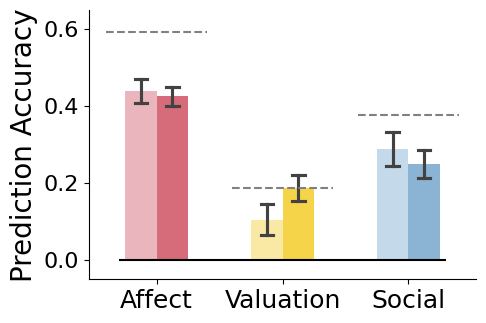

saved inhouse_BNA


In [4]:
plot_one('inhouse_BNA', CEILING_INHOUSE)

## inhouse_HOA

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


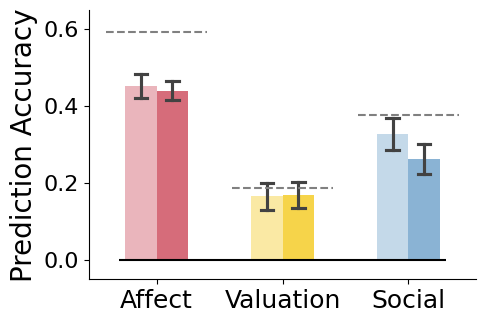

saved inhouse_HOA


In [5]:
plot_one('inhouse_HOA', CEILING_INHOUSE)

## HCP3T_BNA

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


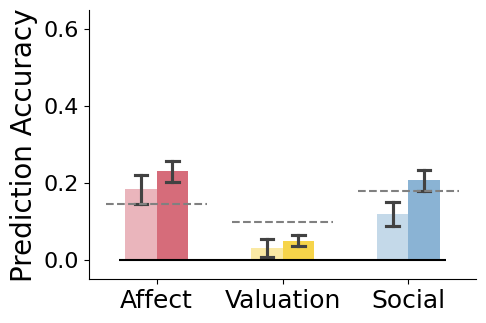

saved HCP3T_BNA


In [6]:
plot_one('HCP3T_BNA', CEILING_HCP)

## inhouse_predict_HCP_3T_BNA

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


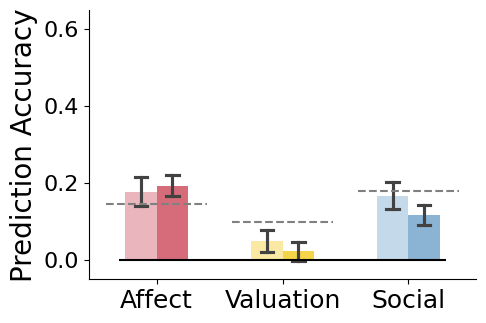

saved inhouse_predict_HCP_3T_BNA


In [7]:
plot_one('inhouse_predict_HCP_3T_BNA', CEILING_HCP)

## inhouse_predict_HCP_7T_BNA

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


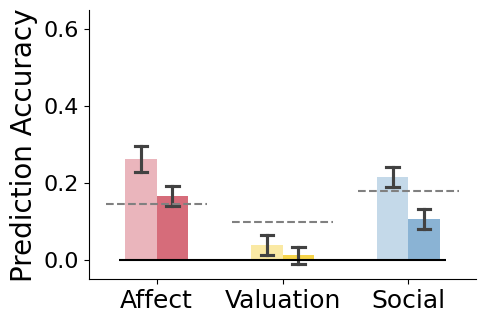

saved inhouse_predict_HCP_7T_BNA


In [8]:
plot_one('inhouse_predict_HCP_7T_BNA', CEILING_HCP)